# Assignment - 2

## Import Libraries

In [8]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

## 1. Getting the data

In [9]:
df = pd.read_csv("german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [11]:
print(df.columns)

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 11


In [13]:
print(df["Risk"].value_counts())

Risk
good    700
bad     300
Name: count, dtype: int64


## 2. Select the text data

In [14]:
print(df["Purpose"].unique())

['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']


In [15]:
df["Purpose"] = df["Purpose"].fillna("unknown")

In [16]:
text_data = df["Purpose"].astype(str)
text_data.head(10)

,Purpose
0,radio/TV
1,radio/TV
2,education
3,furniture/equipment
4,car
5,education
6,furniture/equipment
7,car
8,radio/TV
9,car


## 3. Data Cleaning

#### Convert to lowercase

In [17]:
text_lower = text_data.str.lower()
text_lower.head()

,Purpose
0,radio/tv
1,radio/tv
2,education
3,furniture/equipment
4,car


#### Remove Punctuation and Numbers

In [18]:
def clean_text_round1(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [19]:
text_clean = text_data.apply(clean_text_round1)
text_clean.head(10)

,Purpose
0,radiotv
1,radiotv
2,education
3,furnitureequipment
4,car
5,education
6,furnitureequipment
7,car
8,radiotv
9,car


#### Additional Regular Expression

In [20]:
def clean_text_round2(text):
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [21]:
text_clean = text_clean.apply(clean_text_round2)
text_clean.head(10)

,Purpose
0,radiotv
1,radiotv
2,education
3,furnitureequipment
4,car
5,education
6,furnitureequipment
7,car
8,radiotv
9,car


#### Tokenization

In [22]:
tokens = text_clean.apply(lambda text: text.split())
tokens.head(10)

,Purpose
0,[radiotv]
1,[radiotv]
2,[education]
3,[furnitureequipment]
4,[car]
5,[education]
6,[furnitureequipment]
7,[car]
8,[radiotv]
9,[car]


#### Remove Stop Words

In [23]:
stop_words = set(ENGLISH_STOP_WORDS)
tokens_without_stopwords = tokens.apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

In [24]:
tokens_without_stopwords.head(10)

,Purpose
0,[radiotv]
1,[radiotv]
2,[education]
3,[furnitureequipment]
4,[car]
5,[education]
6,[furnitureequipment]
7,[car]
8,[radiotv]
9,[car]


#### Convert tokens back to text

In [25]:
clean_text = tokens_without_stopwords.apply(
    lambda words: " ".join(words)
)
clean_text.head(10)

,Purpose
0,radiotv
1,radiotv
2,education
3,furnitureequipment
4,car
5,education
6,furnitureequipment
7,car
8,radiotv
9,car


#### Create the corpus

In [26]:
corpus = pd.DataFrame({
    "original_text": text_data,
    "clean_text": clean_text,
    "Risk": df["Risk"]
})
corpus.head(10)

,original_text,clean_text,Risk
0,radio/TV,radiotv,good
1,radio/TV,radiotv,bad
2,education,education,good
3,furniture/equipment,furnitureequipment,good
4,car,car,bad
5,education,education,good
6,furniture/equipment,furnitureequipment,good
7,car,car,good
8,radio/TV,radiotv,good
9,car,car,bad


#### Check the corpus

In [29]:
print("Number of documents:", len(corpus))
print("\nFirst few documents:")
print(corpus.head())
print()
print(corpus["clean_text"].value_counts())

Number of documents: 1000

First few documents:
         original_text          clean_text  Risk
0             radio/TV             radiotv  good
1             radio/TV             radiotv   bad
2            education           education  good
3  furniture/equipment  furnitureequipment  good
4                  car                 car   bad

clean_text
car                    337
radiotv                280
furnitureequipment     181
business                97
education               59
repairs                 22
domestic appliances     12
vacationothers          12
Name: count, dtype: int64


#### Create the Document-Term Matrix

In [30]:
vectorizer = CountVectorizer()
dtm = vectorizer.fit_transform(corpus["clean_text"])

In [31]:
print("DTM shape:", dtm.shape)

DTM shape: (1000, 9)


#### View the vocabulary

In [32]:
words = vectorizer.get_feature_names_out()
print(words)

['appliances' 'business' 'car' 'domestic' 'education' 'furnitureequipment'
 'radiotv' 'repairs' 'vacationothers']


#### Convert DTM into a Pandas Dataframe

In [33]:
dtm_df = pd.DataFrame(
    dtm.toarray(),
    columns=words
)
dtm_df.head()

,appliances,business,car,domestic,education,furnitureequipment,radiotv,repairs,vacationothers
0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0,0,0


#### Fint the most common words

In [34]:
word_counts = dtm_df.sum().sort_values(ascending=False)
print(word_counts)

car                   337
radiotv               280
furnitureequipment    181
business               97
education              59
repairs                22
appliances             12
domestic               12
vacationothers         12
dtype: int64


In [35]:
print(word_counts.head(10))

car                   337
radiotv               280
furnitureequipment    181
business               97
education              59
repairs                22
appliances             12
domestic               12
vacationothers         12
dtype: int64


#### Plot the most common words

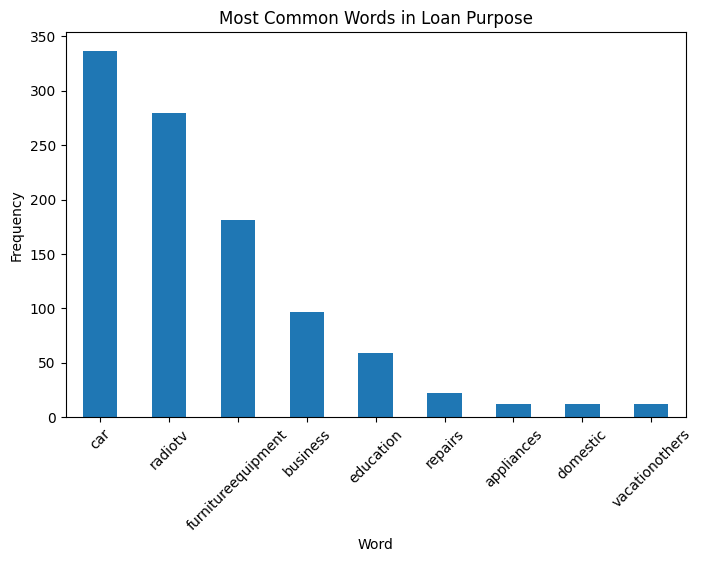

In [36]:
plt.figure(figsize=(8, 5))
word_counts.head(10).plot(kind="bar")
plt.title("Most Common Words in Loan Purpose")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

#### Compare text patterns by risk

In [37]:
purpose_risk = pd.crosstab(
    df["Purpose"],
    df["Risk"]
)
print(purpose_risk)

Risk                 bad  good
Purpose                       
business              34    63
car                  106   231
domestic appliances    4     8
education             23    36
furniture/equipment   58   123
radio/TV              62   218
repairs                8    14
vacation/others        5     7


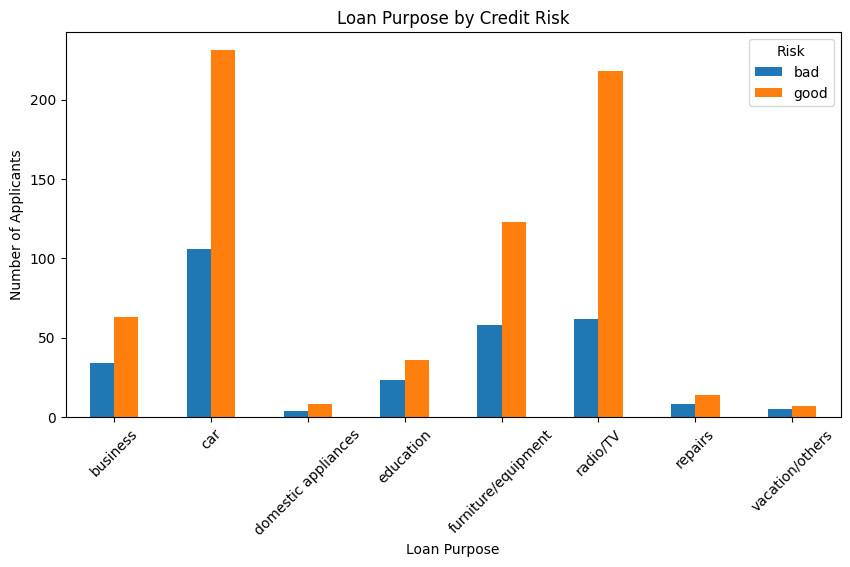

In [38]:
purpose_risk.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Loan Purpose by Credit Risk")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=45)

plt.show()

## Q3. Additional Regular Expression

In [40]:
def clean_text_round2(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [41]:
text_clean = text_data.apply(clean_text_round1)
text_clean = text_clean.apply(clean_text_round2)

text_clean.head()

,Purpose
0,radiotv
1,radiotv
2,education
3,furnitureequipment
4,car


## Q4. ngram_range

#### Unigrams

In [42]:
vectorizer_1 = CountVectorizer(
    ngram_range=(1, 1)
)

dtm_1 = vectorizer_1.fit_transform(clean_text)

print(vectorizer_1.get_feature_names_out())

['appliances' 'business' 'car' 'domestic' 'education' 'furnitureequipment'
 'radiotv' 'repairs' 'vacationothers']


#### Bigrams

In [43]:
vectorizer_2 = CountVectorizer(
    ngram_range=(2, 2)
)

dtm_2 = vectorizer_2.fit_transform(clean_text)

print(vectorizer_2.get_feature_names_out())

['domestic appliances']


#### Unigrams + Bigrams

In [44]:
vectorizer_3 = CountVectorizer(
    ngram_range=(1, 2)
)

dtm_3 = vectorizer_3.fit_transform(clean_text)

print(vectorizer_3.get_feature_names_out())

['appliances' 'business' 'car' 'domestic' 'domestic appliances'
 'education' 'furnitureequipment' 'radiotv' 'repairs' 'vacationothers']


#### Experiment with **min_df**

In [45]:
vectorizer_min = CountVectorizer(
    min_df=2
)

dtm_min = vectorizer_min.fit_transform(clean_text)

print(vectorizer_min.get_feature_names_out())

['appliances' 'business' 'car' 'domestic' 'education' 'furnitureequipment'
 'radiotv' 'repairs' 'vacationothers']


#### Experiment with **max_df**

In [46]:
vectorizer_max = CountVectorizer(
    max_df=0.8
)

dtm_max = vectorizer_max.fit_transform(clean_text)

print(vectorizer_max.get_feature_names_out())

['appliances' 'business' 'car' 'domestic' 'education' 'furnitureequipment'
 'radiotv' 'repairs' 'vacationothers']


#### Combine all parameters

In [47]:
vectorizer_final = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

dtm_final = vectorizer_final.fit_transform(clean_text)

dtm_final_df = pd.DataFrame(
    dtm_final.toarray(),
    columns=vectorizer_final.get_feature_names_out()
)

dtm_final_df.head()

,appliances,business,car,domestic,domestic appliances,education,furnitureequipment,radiotv,repairs,vacationothers
0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0
4,0,0,1,0,0,0,0,0,0,0


In [48]:
print("Rows:", dtm_final_df.shape[0])
print("Terms:", dtm_final_df.shape[1])

Rows: 1000
Terms: 10


#### Compare different settings

In [50]:
settings = [
    {"ngram_range": (1, 1)},
    {"ngram_range": (1, 2)},
    {"ngram_range": (1, 2), "min_df": 2},
    {"ngram_range": (1, 2), "min_df": 2, "max_df": 0.8}
]

for setting in settings:
    vectorizer = CountVectorizer(**setting)
    matrix = vectorizer.fit_transform(clean_text)
    print(setting,"->",matrix.shape[1],"terms")

{'ngram_range': (1, 1)} -> 9 terms
{'ngram_range': (1, 2)} -> 10 terms
{'ngram_range': (1, 2), 'min_df': 2} -> 10 terms
{'ngram_range': (1, 2), 'min_df': 2, 'max_df': 0.8} -> 10 terms


## Final Clean Dataset

In [51]:
final_data = corpus.copy()
final_data["clean_text"] = clean_text
final_data.to_csv(
    "cleaned_credit_text.csv",
    index=False
)
print("Cleaned data saved successfully.")

Cleaned data saved successfully.
